In [20]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn.functional as F
from torch.distributions import Normal
import random
import numpy as np
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
import rl_utils

Why correct log_prob? In probability theory, if you perform a nonlinear transformation on a random variable (here, $a = \tanh(u)$), its probability density will also change. Without correction, the calculated entropy will be incorrect. According to the Change of Variables theorem, the new probability density is equal to the original probability density divided by the derivative of the transformation function. Since $\frac{d}{du} \tanh(u) = 1 - \tanh^2(u)$, the formula after taking the logarithm is derived as follows: $$\log \pi(a|s) = \log p(u|s) - \log \left( 1 - \tanh^2(u) \right)$$ The 1e-7 in the code is a very small constant (Epsilon), to prevent $\log(0)$ from causing the program to crash (NaN error).

In [21]:
class PolicyNetContinuous(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim,action_bound):
        super(PolicyNetContinuous,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim,action_dim)
        self.fc_std = torch.nn.Linear(hidden_dim,action_dim)
        self.action_bound = action_bound 

    def forward(self,x):
        x = F.relu(self.fc1(x))
        mu = self.fc_mu(x)
        std = F.softplus(self.fc_std(x))
        dist = Normal(mu,std)
        # do reparameteriation
        normal_sample = dist.rsample()
        log_prob = dist.log_prob(normal_sample)
        action = torch.tanh(normal_sample)
        log_prob = log_prob - torch.log(1 - torch.tanh(action).pow(2) + 1e-7)
        action = action * self.action_bound
        return action,log_prob
    
class QValueNetContinuous(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(QValueNetContinuous,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim+action_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim,1)

    def forward(self,x,a):
        cat = torch.cat([x,a],dim=1)
        x = F.relu(self.fc1(cat))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)

In [22]:
class SACContinuous:
    def __init__(self,state_dim,hidden_dim,action_dim,action_bound,
                 actor_lr,critic_lr,alpha_lr,target_entropy,tau,gamma,device):
        self.actor = PolicyNetContinuous(state_dim,hidden_dim,action_dim,action_bound).to(device)
        self.critic1 = QValueNetContinuous(state_dim,hidden_dim,action_dim).to(device)
        self.critic2 = QValueNetContinuous(state_dim,hidden_dim,action_dim).to(device)
        self.target_critic1 = QValueNetContinuous(state_dim,hidden_dim,action_dim).to(device)
        self.target_critic2 = QValueNetContinuous(state_dim,hidden_dim,action_dim).to(device)

        self.target_critic1.load_state_dict(self.critic1.state_dict())
        self.target_critic2.load_state_dict(self.critic2.state_dict())

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=actor_lr)
        self.critic1_optimizer = torch.optim.Adam(self.critic1.parameters(),lr=critic_lr)
        self.critic2_optimizer = torch.optim.Adam(self.critic2.parameters(),lr=critic_lr)

        self.log_alpha = torch.tensor(np.log(0.01),dtype= torch.float32)
        self.log_alpha.requires_grad = True
        self.log_alpha_optimizer = torch.optim.Adam([self.log_alpha],lr=alpha_lr)  ###################

        self.target_entropy = target_entropy
        self.gamma = gamma
        self.tau = tau
        self.device = device

    def take_action(self,state):
        state = torch.tensor(np.array(state),dtype=torch.float32).unsqueeze(0).to(self.device)
        action = self.actor(state)[0]
        return [action.item()]
    
    def calc_target(self,rewards,next_states,dones):
        next_actions,log_prob = self.actor(next_states)
        entropy = -log_prob
        q1_value = self.target_critic1(next_states,next_actions)
        q2_value = self.target_critic2(next_states,next_actions)
        next_value = torch.min(q1_value,q2_value) + self.log_alpha.exp() * entropy
        td_target = rewards + self.gamma * next_value * (1-dones)

        return td_target
    
    def soft_update(self,net,target_net):
        for param_target,param in zip(target_net.parameters(),net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) + param.data * self.tau)
    
    def update(self,transition_dict):
        states = torch.tensor(np.array(transition_dict['states']), dtype=torch.float32).to(self.device)
        actions = torch.tensor(np.array(transition_dict['actions']), dtype=torch.float32).view(-1, 1).to(self.device)
        rewards = torch.tensor(np.array(transition_dict['rewards']), dtype=torch.float32).view(-1, 1).to(self.device)
        next_states = torch.tensor(np.array(transition_dict['next_states']), dtype=torch.float32).to(self.device)
        dones = torch.tensor(np.array(transition_dict['dones']), dtype=torch.float32).view(-1, 1).to(self.device)


        #update critic
        rewards = (rewards + 8.0) / 8.0

        td_target = self.calc_target(rewards,next_states,dones)
        critic_1_loss = torch.mean(F.mse_loss(self.critic1(states,actions),td_target.detach()))
        critic_2_loss = torch.mean(F.mse_loss(self.critic2(states,actions),td_target.detach()))
        self.critic1_optimizer.zero_grad()
        critic_1_loss.backward()
        self.critic1_optimizer.step()
        self.critic2_optimizer.zero_grad()
        critic_2_loss.backward()
        self.critic2_optimizer.step()


        #update actor
        new_actions,log_prob = self.actor(states)
        entropy = -log_prob
        q1_value = self.critic1(states, new_actions)
        q2_value = self.critic2(states, new_actions)
        actor_loss = torch.mean(-self.log_alpha.exp() * entropy -
                                torch.min(q1_value, q2_value))
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # update alpha
        alpha_loss = torch.mean(
            (entropy - self.target_entropy).detach() * self.log_alpha.exp())
        self.log_alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

        self.soft_update(self.critic1, self.target_critic1)
        self.soft_update(self.critic2, self.target_critic2)



In [ ]:
env_name = 'Pendulum-v1'
env = gym.make(env_name)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # maximum of action
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

actor_lr = 3e-4
critic_lr = 3e-3
alpha_lr = 3e-4
num_episodes = 200
hidden_dim = 128
gamma = 0.99
tau = 0.005  # soft update parameter
buffer_size = 100000
minimal_size = 1000
batch_size = 64
target_entropy = -env.action_space.shape[0]

if(torch.cuda.is_available()):
    device = 'cuda'
elif(torch.backends.mps.is_available()):
    device = 'mps'
else:
    device = 'cpu'
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
agent = SACContinuous(state_dim, hidden_dim, action_dim, action_bound,
                      actor_lr, critic_lr, alpha_lr, target_entropy, tau,
                      gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes,
                                              replay_buffer, minimal_size,
                                              batch_size)

Iteration 9: 100%|██████████| 20/20 [00:05<00:00,  3.45it/s, episode=200, return=-187.683]


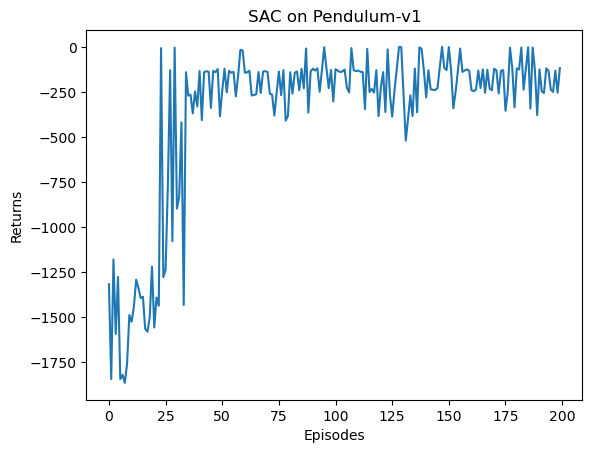

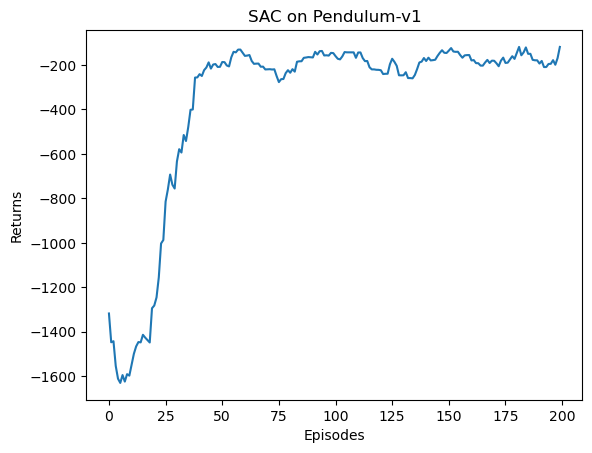

In [24]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('SAC on {}'.format(env_name))
plt.show()

much more fast and stable than DDPG, more robust after convergence.